# Dynamics for a Non integrable Hamiltonian

#### Imports

In [26]:
from qutip_class import SpinOperator,SpinHamiltonian,SteadyStateSolver
import numpy as np
import qutip
from tqdm import tqdm
from typing import Dict,List,Tuple,Union
import matplotlib.pyplot as plt
from qutip.solver import Options


#### Hyperparameters

Hermitian Check positive! well done! 

Quantum object: dims = [[2, 2, 2, 2, 2], [2, 2, 2, 2, 2]], shape = (32, 32), type = oper, isherm = True
Qobj data =
[[2.5 0.  0.  ... 0.  0.  0. ]
 [0.  0.5 0.  ... 0.  0.  0. ]
 [0.  0.  0.5 ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.5 0.  0. ]
 [0.  0.  0.  ... 0.  0.5 0. ]
 [0.  0.  0.  ... 0.  0.  2.5]]
Quantum object: dims = [[2, 2, 2, 2, 2], [2, 2, 2, 2, 2]], shape = (32, 32), type = oper, isherm = True
Qobj data =
[[0. 1. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 1. 1. 0.]]
Quantum object: dims = [[2, 2, 2, 2, 2], [2, 2, 2, 2, 2]], shape = (32, 32), type = oper, isherm = True
Qobj data =
[[2.5 1.  1.  ... 0.  0.  0. ]
 [1.  0.5 0.  ... 0.  0.  0. ]
 [1.  0.  0.5 ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.5 0.  1. ]
 [0.  0.  0.  ... 0.  0.5 1. ]
 [0.  0.  0.  ... 1.  1.  2.5]]
eig= [-5.30994062 -3.99721204 -3.99721204 -2.82813103 -2.82813103 -2.3698

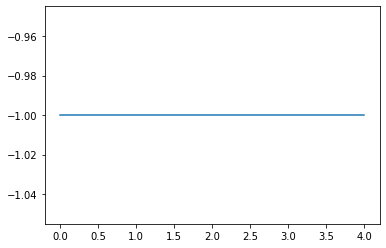

In [45]:
size:int=5
pbc:bool=False
j:float=-1.
coupling_noise:float=1.
dir_coupling:Tuple[str]=('x','x')
dir_field:str='z'

tf=10.
dt=0.001
t:np.ndarray = np.linspace(0, tf, int(tf/dt))
hi:float=100.
hf:float=1.


#observables
obs:List[qutip.Qobj]=[]
#zz=SpinOperator(index=[('z',int(size/2),'z',int(size/2)+1)],coupling=[1.],size=size)
#obs.append(zz.qutip_op)

    

class RealQuench:
    def __init__(
        self,
        hi: Union[float, np.ndarray],
        hf: Union[float, np.ndarray],
    ) -> None:

        self.hi: Union[np.ndarray, float] = hi
        self.hf: Union[np.ndarray, float] = hf

    def field(self, t: float,args) -> Union[np.ndarray, float]:
        if t==0:
            return self.hi
        else:
            return self.hf

        
ham0=SpinHamiltonian(direction_couplings=[('z','z')],pbc=True,coupling_values=[1/2],size=size,verbose=1)
h1=SpinHamiltonian(field_directions=['x'],field_values=[1/2],size=size,pbc=False,verbose=1)

print(ham0.qutip_op)
print(h1.qutip_op)

field_coeff=RealQuench(hi=hi,hf=hf)

ham=[ham0.qutip_op,[h1.qutip_op,field_coeff.field]]

print(ham0.qutip_op+h1.qutip_op)
_,psi0=np.linalg.eigh(ham0.qutip_op+100*h1.qutip_op)

eig,eigvectors=np.linalg.eigh(ham0.qutip_op+h1.qutip_op)

print('eig=',eig,'eigvectors=',eigvectors,'\n')

i_min=np.argmin(eig)

print(i_min)

psi0=psi0[:,i_min]

print(psi0)


psi=qutip.Qobj(psi0,shape=psi0.shape,dims=([[2 for i in range(size)],[1]]))

for r in np.isnan(psi0):
    if r==True:
        print(r) 

x_gs=[]

for i in range(size):
    x=SpinOperator(index=[('x',i)],coupling=[1],size=size,verbose=1)
    obs.append(x.qutip_op)
    x_gs.append(x.expect_value(psi))
    
plt.plot(x_gs)
    


#### Evolution

In [46]:
#options = Options(num_cpus=4, atol=1e-20)

output=qutip.sesolve(ham,psi,t,e_ops=obs)

5


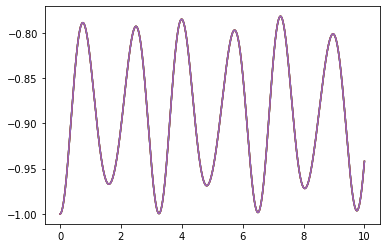

In [47]:
print(len(output.expect))
for i in range(size):
    plt.plot(t,output.expect[i],label=r'$x_$'+f'{i}')
plt.show()